# SETUP

In [3]:
#config
import json
from pathlib import Path
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import sys

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir, recon_for_MAP_dir,recon_for_EVENT_dir, agent_p_output_dir,
    set_pass, pass_num, asset_name
)
from Eval_defs import random_baseline_closed_form,random_baseline_blocks, load_labels,paper_edit_to_timegrid,score_paper_vs_GT_edits,labels_dir,cut_csv_to_timegrid, time_grid,spans_to_mask, annotator_beats_to_grid   # now resolvable
 


case_name =  "503_EGO_noodles_sound" 
experiment = "Pipe_eval_03"
set_case(case_name, experiment)
paper_edit_json_path = agent_p_output_dir() / f"{case_name}_{experiment}_1_revision.json"
ablation = "ablation_01"
ablation_paper_edit_json_path = case_dir() / "012_agent_p_output"/ ablation / f"{case_name}_{ablation}_1_revision.json"

my_cut_csv = labels_dir() / f"{case_name}_cuts.csv"
BIN_S = 1.0      # vote grid, seconds. 0.1 matches the label precision if you want it finer
WEIGHTS = None   # or {"important": 1.0, "critical": 2.0}


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# MY CUT
## VS machine

In [4]:
edges = time_grid(case_name, bin_s=BIN_S, labels=None, tol_s=1.0)
machine_paper_edit = paper_edit_to_timegrid(paper_edit_json_path, case_name, edges)
ablation_paper_edit = paper_edit_to_timegrid(ablation_paper_edit_json_path, case_name, edges)

GT_edit = cut_csv_to_timegrid(my_cut_csv, edges)   # w, 0 or 1
#beta controls f_beta wihc controls soft f1
score_paper_vs_GT_edits(GT_edit, machine_paper_edit)
#f beta is precision and recall together. the F measure
#f-1 is beta =1 same calc but hard coded



503_EGO_noodles_sound: 2/13 beats have no resolved frames — skipped


{'soft_precision': 0.529783393501805,
 'precision': 0.41155234657039713,
 'soft_recall': 0.3252032520325203,
 'recall': 0.3089430894308943,
 'soft_specificity': 0.9220059880239521,
 'specificity': 0.9023952095808383,
 'iou': 0.21428571428571427,
 'soft_f1': 0.40301748182731006,
 'f_beta': 0.3529411764705883,
 'beta': 1.0,
 'decay_s': 4.0,
 'true_p_s': 114.0,
 'false_p_s': 163.0,
 'false_n_s': 255.0,
 'true_n_s': 1507.0,
 'edit_s': 277.0,
 'gt_s': 369.0,
 'len_ratio': 0.7506775067750677,
 'n_segments': 11,
 'shortest_seg_s': 16.0,
 'median_seg_s': 26.0}

# VS humans

In [16]:
decay_s=4
rows = [dict(editor="ME (GT)", time_min=70.0,
             **score_paper_vs_GT_edits(GT_edit, GT_edit, decay_s=decay_s))]

rows.append(dict(editor="machine", time_min=np.nan,
                 **score_paper_vs_GT_edits(GT_edit, machine_paper_edit, decay_s=decay_s)))
rows.append(dict(editor="System: ablation", time_min=np.nan,
                 **score_paper_vs_GT_edits(GT_edit, ablation_paper_edit, decay_s=decay_s)))

for l in load_labels():
    rows.append(dict(editor=l["annotator"],
                     time_min=round(l["time_spent_sec"] / 60, 1),
                     **score_paper_vs_GT_edits(GT_edit, annotator_beats_to_grid(l, edges), decay_s=decay_s)))
rand_row, null_stats, density = random_baseline_blocks(GT_edit, machine_paper_edit)
rand_row, null_stats_ab, density = random_baseline_blocks(GT_edit, ablation_paper_edit)
rows.append(rand_row)
rows.append(dict(editor="whole clip", time_min=np.nan,
                 **score_paper_vs_GT_edits(GT_edit, np.ones_like(GT_edit), decay_s=decay_s)))
comp = pd.DataFrame(rows)
comp[["editor", "time_min", "soft_f1",
      "soft_specificity", 
      "soft_precision",
      "soft_recall", 
      "iou", "len_ratio", "n_segments", "median_seg_s", "edit_s"]].round(3)



,editor,time_min,soft_f1,soft_specificity,soft_precision,soft_recall,iou,len_ratio,n_segments,median_seg_s,edit_s
0,ME (GT),70.0,1.000,1.000,1.000,1.000,1.000,1.000,39.00,8.000,369.0
1,machine,NaN,0.403,0.922,0.530,0.325,0.214,0.751,11.00,26.000,277.0
2,System: ablation,NaN,0.451,0.781,0.399,0.519,0.238,1.650,20.00,31.000,609.0
3,George,84.1,0.397,0.836,0.361,0.441,0.202,1.160,26.00,12.500,428.0
4,Vuk,8.7,0.262,0.849,0.287,0.241,0.121,0.959,14.00,27.000,354.0
5,stefanos,6.7,0.400,0.278,0.258,0.892,0.195,4.401,8.00,181.500,1624.0
6,"random (blocks, n=200)",NaN,0.276,0.722,0.238,0.329,0.129,1.650,19.73,31.212,609.0
7,whole clip,NaN,0.382,0.067,0.236,1.000,0.181,5.526,1.00,2039.000,2039.0


In [15]:
#null_stats
null_stats_ab

,Producer_agent_score,mean,p05,p95,pct
iou,0.238,0.129,0.084,0.187,99.5
soft_f1,0.451,0.276,0.201,0.373,99.5
precision,0.309,0.182,0.125,0.253,99.5
recall,0.509,0.301,0.206,0.418,99.5
specificity,0.748,0.702,0.681,0.728,99.5


saved /workspace/project/writing/Figures/sys_eval/503_EGO_noodles_sound_edit_overlaps.pdf


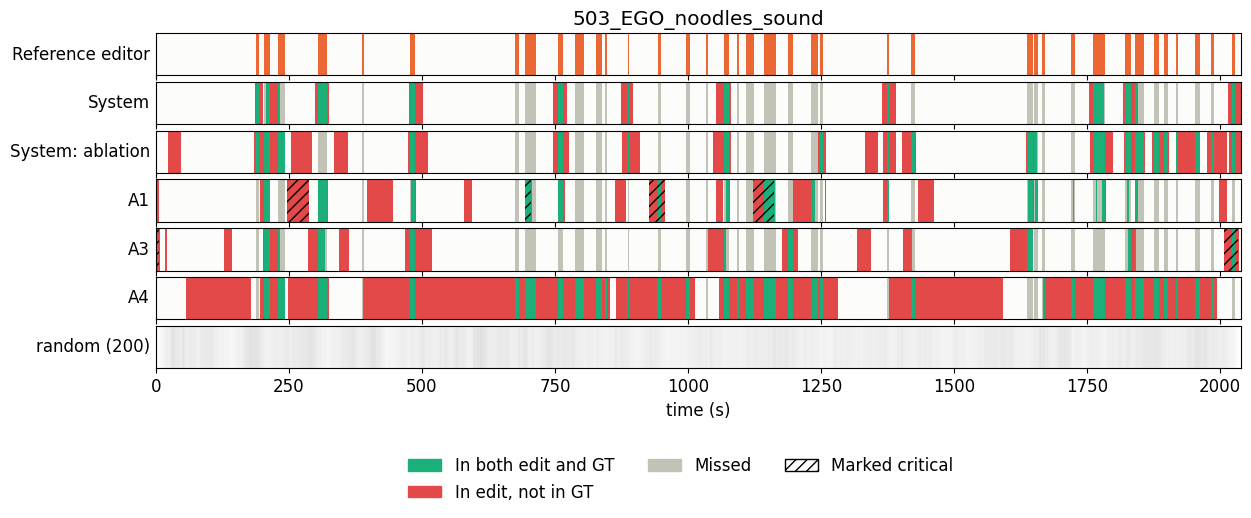

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from Eval_defs import timeline_agreement
TP_C, FP_C, FN_C, REF_C = "#1baf7a", "#e34948", "#c3c2b7", "#eb6834"


import matplotlib.pyplot as plt
from matplotlib.patches import Patch

tracks = {"ME (GT)": GT_edit, "machine": machine_paper_edit,"System: ablation" : ablation_paper_edit}
for l in load_labels():
    tracks[l["annotator"]] = annotator_beats_to_grid(l, edges)
tracks["random (200)"] = density
timeline_agreement(case_name, edges, tracks, GT_edit=GT_edit,
                   fname=f"{asset_name()}_edit_overlaps.pdf")




In [8]:
cols = ["editor", "time_min", "edit_s", "len_ratio",
        "soft_f1", "soft_precision", "soft_recall", "soft_specificity",
        "iou", "n_segments", "median_seg_s"]

nice = {"editor": "Editor", "time_min": "Time (min)", "edit_s": "Cut (s)",
        "len_ratio": "Len ratio", "soft_f1": "Soft $F_1$",
        "soft_precision": "Soft prec.", "soft_recall": "Soft rec.",
        "soft_specificity": "Soft spec.", "iou": "IoU",
        "n_segments": "Shots", "median_seg_s": "Median shot (s)"}

(comp[cols].rename(columns=nice)
 .to_latex(project_root / "writing" /"Figures" / "sys_eval"/ f"{case_name}_{experiment}_table_comp.tex",
           index=False, escape=False, float_format="%.3f",
           column_format="lrrrrrrrrrr",
           caption=f"Editors scored against the reference cut, {case_name}",
           label="tab:noodles_comp",
           position="htbp"))


In [9]:
%load_ext autoreload
%autoreload 2
from Eval_defs import GT_paper_edit, compare_map_beats, paper_edit_path


map_df = compare_map_beats(GT_paper_edit_json_path,
                           (ablation_paper_edit_json_path, paper_edit_json_path),
                           label_a="GT", label_b=("System: ablation","System"),
                           case_name=case_name, fname=f"{case_name}_map_beats.png")

map_df


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


NameError: name 'GT_paper_edit_json_path' is not defined

In [10]:
from Eval_defs import repeated_frame_counts, repeated_frame_pairs
repeated_frame_counts(ablation_paper_edit_json_path)
repeated_frame_pairs(ablation_paper_edit_json_path)


Repeated frames 0 
 total frames 17687 
 %repeated: 0.0


[]